# **Day 93: Project 2 - Crop-Type Mapping (Part 2): Deep Temporal Models, Transfer and Early-Season Mapping**
*Module 13 - Remote Sensing ML and Publication Projects*

Day 92 established strong random-forest baselines and showed that the **year-to-year shift** in sowing dates is the main enemy. Today we answer **RQ3** with deep learning on the same parcels:
- **TempCNN** (Pelletier et al. 2019): 1-D convolutions over time; the reference deep model for crop time series
- **LSTM**: a recurrent model (Day 65)
- **Transformer** with day-of-year positional encoding (in the spirit of the attention models of Rußwurm & Körner 2020 and Garnot et al. 2020)

and two questions that matter to agencies:
1. Does **temporal augmentation** (random time shifts in training) make models robust to a late monsoon?
2. **How early** in the season can each crop be mapped?

> Deep temporal models (1-D CNNs, LSTMs and Transformers) learn directly from the whole time series. We also ask how early in the season crops can be identified, which matters for crop forecasts.
>
> *Example:* By the end of August the model may already recognise rice from the flooding signal, while wheat can only be identified after it is sown in winter.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy, sys, time, json
from pathlib import Path
import torch, torch.nn as nn, torch.nn.functional as F
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
import rs_utils as ru
ru.pub_style()
PROJ = Path("project2_crop"); sys.path.insert(0, str(PROJ))
import crop_ts as ct
torch.set_num_threads(4)

ts = np.load(PROJ / "data/timeseries.npz")
s2, s2_days, s1, s1_days = ts["s2"], ts["s2_days"], ts["s1"], ts["s1_days"]
import geopandas as gpd
parcels = gpd.read_file(PROJ / "data/parcels.gpkg")
y = parcels["crop_id"].values.astype(np.int64); year = parcels["year"].values; region = parcels["region"].values
K = len(ru.CROP_CLASSES)

## **1. Tensors and Splits**
We reuse the Day 92 preprocessing (outlier screening + Whittaker) and resample S2 (6 bands + NDVI) and S1 (VV, VH) to a 10-day grid: **T = 37 steps, C = 9 channels**.

Splits (the same for every model):
- **train / validation**: 2024, regions A and B. Validation = 20% of the 2 km spatial blocks, used only for early stopping.
- **test "new region"**: 2024, region C
- **test "new year"**: 2023, regions A and B (same places, late monsoon)

In [2]:
s2_clean = ct.screen_outliers(s2)
sm = ct.smooth_all(s2_clean)
grid = np.arange(0, 365, 10)
X = np.concatenate([ct.to_grid(sm, s2_days, grid), ct.to_grid(s1, s1_days, grid)], -1).astype(np.float32)
CH = ct.S2_BANDS + ["NDVI", "VV", "VH"]
blocks = ru.spatial_blocks(parcels.geometry.x.values, parcels.geometry.y.values, 2000)
rng = np.random.default_rng(0)
pool = np.flatnonzero((year == 2024) & np.isin(region, ["A", "B"]))
val_blocks = rng.choice(np.unique(blocks[pool]), int(0.2 * len(np.unique(blocks[pool]))), replace=False)
i_val = pool[np.isin(blocks[pool], val_blocks)]; i_tr = pool[~np.isin(blocks[pool], val_blocks)]
tests = {"new region (2024 C)": np.flatnonzero((year == 2024) & (region == "C")),
         "new year (2023 A+B)": np.flatnonzero((year == 2023) & np.isin(region, ["A", "B"]))}
mu, sd = X[i_tr].mean((0, 1)), X[i_tr].std((0, 1)) + 1e-6
Xn = (X - mu) / sd                                                                # statistics from the training split only
print(f"X {X.shape} | train {len(i_tr)}, val {len(i_val)}, " + ", ".join(f"{k} {len(v)}" for k, v in tests.items()))

X (5400, 37, 9) | train 1454, val 346, new region (2024 C) 900, new year (2023 A+B) 1800


## **2. Three Architectures**

In [3]:
class TempCNN(nn.Module):
    """Pelletier et al. (2019): 3 x [Conv1d - BatchNorm - ReLU - Dropout] -> Dense -> softmax."""
    def __init__(self, c_in, n_cls, T, h=64, k=5, drop=0.3):
        super().__init__(); layers, c = [], c_in
        for _ in range(3):
            layers += [nn.Conv1d(c, h, k, padding=k // 2), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(drop)]; c = h
        self.conv = nn.Sequential(*layers)
        self.head = nn.Sequential(nn.Flatten(), nn.Linear(h * T, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(drop), nn.Linear(128, n_cls))
    def forward(self, x, mask=None):                                              # x: (B, T, C)
        return self.head(self.conv(x.transpose(1, 2)))

class LSTMClassifier(nn.Module):
    def __init__(self, c_in, n_cls, h=64):
        super().__init__(); self.lstm = nn.LSTM(c_in, h, num_layers=2, batch_first=True, dropout=0.2); self.fc = nn.Linear(h, n_cls)
    def forward(self, x, mask=None):
        _, (hn, _) = self.lstm(x); return self.fc(hn[-1])

def day_encoding(days, d):
    i = torch.arange(d // 2, dtype=torch.float32); ang = torch.as_tensor(days, dtype=torch.float32)[..., None] / (1000 ** (2 * i / d))
    return torch.cat([ang.sin(), ang.cos()], -1)

class TransformerClassifier(nn.Module):
    """Linear embedding + day-of-year sinusoidal encoding + Transformer encoder + masked mean pooling."""
    def __init__(self, c_in, n_cls, days, d=64, heads=4, layers=2, drop=0.1):
        super().__init__(); self.inp = nn.Linear(c_in, d); self.register_buffer("pe", day_encoding(days, d))
        layer = nn.TransformerEncoderLayer(d, heads, 2 * d, drop, batch_first=True)
        self.enc = nn.TransformerEncoder(layer, layers, enable_nested_tensor=False); self.fc = nn.Linear(d, n_cls)
    def forward(self, x, mask=None, days=None):                                    # mask: (B, T) True = ignore
        pe = self.pe if days is None else day_encoding(days, self.pe.shape[-1])
        h = self.enc(self.inp(x) + pe, src_key_padding_mask=mask)
        if mask is None: return self.fc(h.mean(1))
        keep = (~mask).float().unsqueeze(-1); return self.fc((h * keep).sum(1) / keep.sum(1).clamp(min=1))

T, C = Xn.shape[1:]
makers = {"TempCNN": lambda: TempCNN(C, K, T), "LSTM": lambda: LSTMClassifier(C, K), "Transformer": lambda: TransformerClassifier(C, K, grid)}
for n, mk in makers.items(): print(f"{n:<12} {sum(p.numel() for p in mk().parameters()):>8,} parameters")

TempCNN       348,549 parameters
LSTM           52,805 parameters
Transformer    67,909 parameters


## **3. Training with Early Stopping and Augmentation**
**Temporal augmentation**: shift each training series by a random number of 10-day steps (up to +/-3, i.e. +/-30 days), padding with the edge values. The model then sees "early" and "late" versions of every season and must rely on the **shape** of the curve rather than on calendar dates.

In [4]:
def time_shift(x, max_shift=3):
    B, T_, C_ = x.shape; s = torch.randint(-max_shift, max_shift + 1, (B,))
    idx = (torch.arange(T_)[None] - s[:, None]).clamp(0, T_ - 1)
    return torch.gather(x, 1, idx[..., None].expand(B, T_, C_))

def random_truncation(x, min_steps=4):
    """Mask all steps after a random cut-off (early-season training)."""
    B, T_, _ = x.shape; cut = torch.randint(min_steps, T_ + 1, (B,))
    return torch.arange(T_)[None] >= cut[:, None]

@torch.no_grad()
def predict(model, Xa, mask=None, bs=512):
    model.eval(); out = []
    for b in range(0, len(Xa), bs):
        xb = torch.as_tensor(Xa[b:b + bs]); mb = None if mask is None else torch.as_tensor(mask[b:b + bs])
        out.append(model(xb, mb).softmax(-1))
    return torch.cat(out).numpy()

def train(make, Xa, idx_tr, idx_va, seed=0, epochs=60, lr=2e-3, bs=128, augment=False, truncate=False, patience=10, mask_all=None, drop_obs=0.0):
    """mask_all: optional (N, T) bool array of observations to ignore (e.g. clouds); drop_obs: share of extra random drops."""
    torch.manual_seed(seed); np.random.seed(seed)
    model = make(); opt = torch.optim.AdamW(model.parameters(), lr, weight_decay=1e-3)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    xt, yt = torch.as_tensor(Xa[idx_tr]), torch.as_tensor(y[idx_tr])
    best, state, wait = -1, None, 0
    for ep in range(epochs):
        model.train(); perm = torch.randperm(len(xt))
        for b in range(0, len(perm), bs):
            j = perm[b:b + bs]; xb = xt[j]
            if augment: xb = time_shift(xb)
            mb = None if mask_all is None else torch.as_tensor(mask_all[idx_tr][j.numpy()])
            if mb is not None and drop_obs: mb = mb | (torch.rand(mb.shape) < drop_obs)
            if truncate: mb = random_truncation(xb) if mb is None else mb | random_truncation(xb)
            if mb is not None: mb[mb.all(1), 0] = False                             # never mask a whole series
            loss = F.cross_entropy(model(xb, mb), yt[j], label_smoothing=0.05)
            opt.zero_grad(); loss.backward(); opt.step()
        sched.step()
        f1 = f1_score(y[idx_va], predict(model, Xa[idx_va], None if mask_all is None else mask_all[idx_va]).argmax(1), average="macro")
        if f1 > best: best, state, wait = f1, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= patience: break
    model.load_state_dict(state); model.best_val, model.epochs_run = best, ep + 1
    return model

## **4. Table 2: Deep Models vs Random Forest (3 Seeds Each)**
A single deep-learning run is not a result: the seed alone can move macro F1 by a point or more. We train every model with 3 seeds and report mean +/- s.d. The random forest gets the same inputs (flattened) and the same splits.

In [5]:
rows = []
t0 = time.perf_counter()
for seed in range(3):
    rf = RandomForestClassifier(300, n_jobs=-1, random_state=seed).fit(X[i_tr].reshape(len(i_tr), -1), y[i_tr])
    rows.append({"model": "RF (flattened)", "augment": False, "seed": seed, **{k: f1_score(y[v], rf.predict(X[v].reshape(len(v), -1)), average="macro") for k, v in tests.items()}})
    for name, mk in makers.items():
        for aug in ([False, True] if name != "LSTM" else [False]):
            m = train(mk, Xn, i_tr, i_val, seed=seed, augment=aug)
            rows.append({"model": name, "augment": aug, "seed": seed, "epochs": m.epochs_run,
                         **{k: f1_score(y[v], predict(m, Xn[v]).argmax(1), average="macro") for k, v in tests.items()}})
print(f"trained {len(rows)} models in {time.perf_counter() - t0:.0f} s")
res = pd.DataFrame(rows)
table2 = res.groupby(["model", "augment"])[list(tests)].agg(["mean", "std"]).round(3)
table2.to_csv(PROJ / "outputs/table2_deep_models.csv"); table2

trained 18 models in 145 s


new region (2024 C)        new year (2023 A+B)       
                                      mean    std                mean    std
model          augment                                                      
LSTM           False                 0.962  0.004               0.896  0.030
RF (flattened) False                 0.966  0.001               0.915  0.003
TempCNN        False                 0.966  0.004               0.957  0.003
               True                  0.972  0.003               0.968  0.000
Transformer    False                 0.966  0.004               0.951  0.002
               True                  0.965  0.003               0.959  0.008

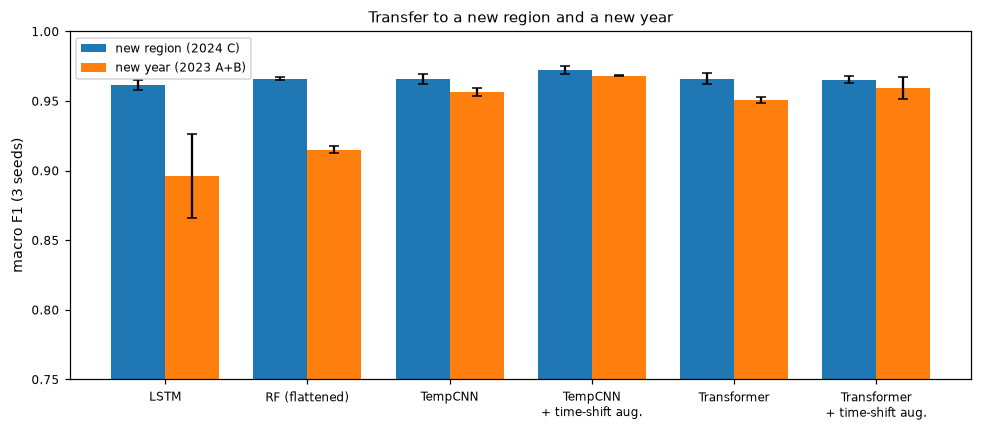

In [6]:
summ = res.groupby(["model", "augment"])[list(tests)].mean()
fig, ax = plt.subplots(figsize=(9, 4)); xk = np.arange(len(summ)); w = 0.38
for j, (k, col) in enumerate(zip(tests, ["tab:blue", "tab:orange"])):
    ax.bar(xk + (j - 0.5) * w, summ[k], w, yerr=res.groupby(["model", "augment"])[k].std(), capsize=3, label=k, color=col)
ax.set_xticks(xk, [f"{m}\n{'+ time-shift aug.' if a else ''}" for m, a in summ.index], fontsize=8); ax.set_ylim(0.75, 1.0)
ax.set_ylabel("macro F1 (3 seeds)"); ax.legend(); ax.set_title("Transfer to a new region and a new year"); plt.tight_layout()
fig.savefig(PROJ / "outputs/fig2_deep_models.png", dpi=300, bbox_inches="tight"); plt.show()

How to read Table 2:
- Compare **within each column**. The "new year" column is the hard, practically relevant one.
- Compare each deep model **with and without augmentation**: the augmentation targets exactly the calendar shift between years.
- Differences smaller than about two standard deviations across seeds should not be claimed as improvements.
- Within the same year, all models score about the same: a well-built RF is hard to beat on a few thousand parcels. The difference appears under **transfer to the late-monsoon year**. Convolutions and attention respond to the *shape* of the seasonal curve wherever it occurs in time, while a forest on flattened dates ties each split to a fixed calendar date. Report both columns: an in-domain comparison alone would hide the main advantage of the temporal models.

## **5. How Early Can We Map? (Early-Season Classification)**
Agencies want crop estimates **before harvest**. Two strategies:
- **RF per cut-off date**: retrain a forest on the data available up to each date (one model per date).
- **One Transformer for all dates**: train with random truncation masks, then predict with the future masked out. One model serves the whole season.

In [7]:
cutoffs = [60, 90, 120, 150, 180, 240, 300, 360]                                   # days since 1 June
tr_model = train(makers["Transformer"], Xn, i_tr, i_val, seed=0, truncate=True, epochs=80, patience=15)
te = tests["new region (2024 C)"]; early = []
for cday in cutoffs:
    steps = int(np.sum(grid <= cday))
    rf_c = RandomForestClassifier(300, n_jobs=-1, random_state=0).fit(X[i_tr, :steps].reshape(len(i_tr), -1), y[i_tr])
    p_rf = rf_c.predict(X[te, :steps].reshape(len(te), -1))
    mask = np.zeros((len(te), T), bool); mask[:, steps:] = True
    p_tr = predict(tr_model, Xn[te], mask).argmax(1)
    early.append({"cut-off day": cday, "date": (pd.Timestamp("2024-06-01") + pd.Timedelta(days=cday)).strftime("%d %b"),
                  "RF (retrained per date)": f1_score(y[te], p_rf, average="macro"), "Transformer (one masked model)": f1_score(y[te], p_tr, average="macro"),
                  **{f"F1 {c} (Transformer)": v for c, v in zip(ru.CROP_CLASSES, f1_score(y[te], p_tr, average=None, labels=range(K)))}})
early = pd.DataFrame(early); early.round(3)

,cut-off day,date,RF (retrained per date),Transformer (one masked model),F1 rice (Transformer),F1 maize (Transformer),F1 pigeon_pea (Transformer),F1 wheat (Transformer),F1 mustard (Transformer)
0,60,31 Jul,0.694,0.706,0.877,0.803,0.885,0.592,0.373
1,90,30 Aug,0.738,0.737,0.917,0.848,0.933,0.562,0.427
2,120,29 Sep,0.820,0.763,0.935,0.903,0.903,0.657,0.416
3,150,29 Oct,0.901,0.885,0.937,0.941,0.945,0.847,0.757
4,180,28 Nov,0.925,0.953,0.968,0.964,0.986,0.935,0.911
5,240,27 Jan,0.964,0.971,0.967,0.957,0.992,0.974,0.963
6,300,28 Mar,0.964,0.969,0.964,0.954,0.989,0.974,0.963
7,360,27 May,0.966,0.966,0.961,0.947,0.983,0.974,0.963


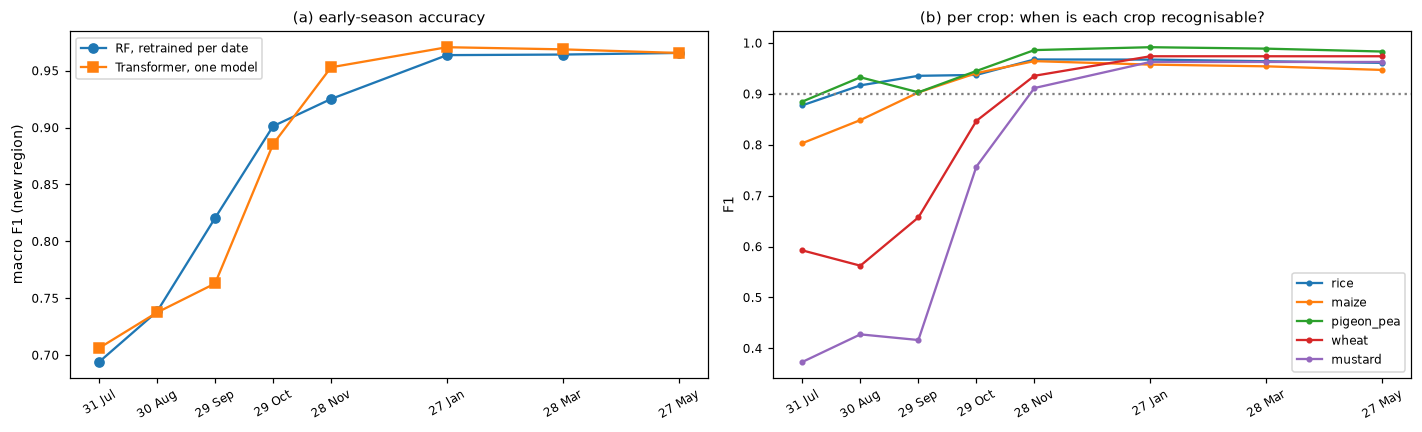

rice       : F1 >= 0.9 from 30 Aug
maize      : F1 >= 0.9 from 29 Sep
pigeon_pea : F1 >= 0.9 from 30 Aug
wheat      : F1 >= 0.9 from 28 Nov
mustard    : F1 >= 0.9 from 28 Nov


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(early["cut-off day"], early["RF (retrained per date)"], "-o", label="RF, retrained per date")
axes[0].plot(early["cut-off day"], early["Transformer (one masked model)"], "-s", label="Transformer, one model")
axes[0].set_xticks(cutoffs, early["date"], rotation=30); axes[0].set_ylabel("macro F1 (new region)"); axes[0].legend(); axes[0].set_title("(a) early-season accuracy")
for c in ru.CROP_CLASSES: axes[1].plot(early["cut-off day"], early[f"F1 {c} (Transformer)"], "-o", ms=3, label=c)
axes[1].axhline(0.9, ls=":", c="gray"); axes[1].set_xticks(cutoffs, early["date"], rotation=30); axes[1].set_ylabel("F1"); axes[1].legend(fontsize=8)
axes[1].set_title("(b) per crop: when is each crop recognisable?"); plt.tight_layout()
fig.savefig(PROJ / "outputs/fig3_early_season.png", dpi=300, bbox_inches="tight"); plt.show()
for c in ru.CROP_CLASSES:
    ok = early[early[f"F1 {c} (Transformer)"] >= 0.9]
    print(f"{c:<11}: F1 >= 0.9 from {ok['date'].iloc[0] if len(ok) else 'never (within this season)'}")

Kharif crops become recognisable from the SAR flooding signal and the monsoon green-up. The rabi crops cannot be told apart before they are sown, so they need the winter data. This crop-by-crop timeline is often the most useful figure in an operational paper.

## **6. Which Dates Matter? Temporal Occlusion**
Replace a 30-day window of one sensor's channels with the training mean (0 after standardisation) and measure the drop in macro F1. It is a model-agnostic attribution over time, and it answers a reviewer's question: what does the model actually look at?

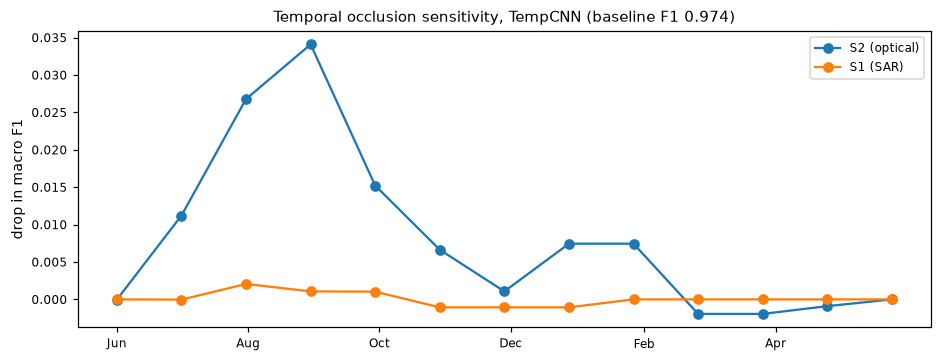

In [9]:
cnn = train(makers["TempCNN"], Xn, i_tr, i_val, seed=0, augment=True)
base = f1_score(y[te], predict(cnn, Xn[te]).argmax(1), average="macro")
sens = {"S2 (optical)": list(range(7)), "S1 (SAR)": [7, 8]}
occl = {k: [] for k in sens}
wins = list(range(0, T, 3))
for k, chs in sens.items():
    for w0 in wins:
        Xo = Xn[te].copy(); Xo[:, w0:w0 + 3][..., chs] = 0
        occl[k].append(base - f1_score(y[te], predict(cnn, Xo).argmax(1), average="macro"))
plt.figure(figsize=(10, 3.5))
for k, v in occl.items(): plt.plot([grid[w] for w in wins], v, "-o", label=k)
plt.xticks([0, 61, 122, 183, 245, 306], ["Jun", "Aug", "Oct", "Dec", "Feb", "Apr"]); plt.ylabel("drop in macro F1")
plt.title(f"Temporal occlusion sensitivity, TempCNN (baseline F1 {base:.3f})"); plt.legend(); plt.show()

# **Part 2: Going Deeper**

## **7. No Gap Filling: a Transformer on Raw, Cloudy Observations**
The Transformer attends over a **set** of observations, each tagged with its date, so it does not need a regular grid. We feed the raw S2 observations (73 dates) and mark the cloudy ones with the padding mask: no interpolation, no smoothing. Real systems use the same idea (e.g. the L-TAE of Garnot & Landrieu 2020).

In [10]:
raw = np.concatenate([s2_clean, ct.ndvi(s2_clean)[..., None]], -1)                 # (N, 73, 7) with NaN
cloud_mask = np.isnan(raw).any(-1)
mu_r, sd_r = np.nanmean(raw[i_tr], (0, 1)), np.nanstd(raw[i_tr], (0, 1))
raw_n = np.nan_to_num((raw - mu_r) / sd_r).astype(np.float32)

m_raw = train(lambda: TransformerClassifier(7, K, s2_days), raw_n, i_tr, i_val, seed=0, mask_all=cloud_mask, drop_obs=0.2)
s2_only_grid = Xn[..., :7]
m_grid = train(lambda: TransformerClassifier(7, K, grid), s2_only_grid, i_tr, i_val, seed=0)
for k, v in tests.items():
    print(f"{k:<20} | S2-only Transformer: raw cloudy series {f1_score(y[v], predict(m_raw, raw_n[v], cloud_mask[v]).argmax(1), average='macro'):.3f} "
          f"vs gap-filled grid {f1_score(y[v], predict(m_grid, s2_only_grid[v]).argmax(1), average='macro'):.3f}")

new region (2024 C)  | S2-only Transformer: raw cloudy series 0.963 vs gap-filled grid 0.961


new year (2023 A+B)  | S2-only Transformer: raw cloudy series 0.945 vs gap-filled grid 0.947


Learning directly from irregular observations is competitive with a hand-tuned gap-filling pipeline, and it removes a preprocessing step that has to be justified in the paper. With S1 added as extra tokens (sensor embedding plus date), this is the basis of current multi-sensor crop models.

## **Practice Problems**
1. Increase the TempCNN kernel size from 5 to 9 (a 90-day receptive field per layer). Does the "new year" score change?
2. Train TempCNN on **S1 channels only** and on **S2 channels only**. Which sensor matters more for the kharif crops, and why?
3. At the 120-day cut-off (late September), which crops does the masked Transformer confuse? Print the confusion matrix.
4. *(Advanced)* **Self-training for the new year**: train on 2024, predict 2023, add the 2023 parcels predicted with probability > 0.95 as pseudo-labels, retrain, and evaluate on 2023. Does it help beyond augmentation?

In [11]:
# Solution 1
m9 = train(lambda: TempCNN(C, K, T, k=9), Xn, i_tr, i_val, seed=0)
v = tests["new year (2023 A+B)"]
print(f"TempCNN k=9 new-year F1 {f1_score(y[v], predict(m9, Xn[v]).argmax(1), average='macro'):.3f} "
      f"(k=5 mean over seeds: {res[(res.model == 'TempCNN') & (~res.augment)]['new year (2023 A+B)'].mean():.3f})")

TempCNN k=9 new-year F1 0.962 (k=5 mean over seeds: 0.957)


In [12]:
# Solution 2
for nm, chs in [("S2 only", list(range(7))), ("S1 only", [7, 8])]:
    m_ = train(lambda: TempCNN(len(chs), K, T), Xn[..., chs], i_tr, i_val, seed=0)
    pr = predict(m_, Xn[te][..., chs]).argmax(1)
    print(f"{nm}: macro F1 {f1_score(y[te], pr, average='macro'):.3f} | kharif-crop F1 " +
          ", ".join(f"{c} {f:.2f}" for c, f in zip(ru.CROP_CLASSES[:3], f1_score(y[te], pr, average=None, labels=range(K))[:3])))

S2 only: macro F1 0.961 | kharif-crop F1 rice 0.95, maize 0.93, pigeon_pea 0.99


S1 only: macro F1 0.941 | kharif-crop F1 rice 0.93, maize 0.89, pigeon_pea 0.98


In [13]:
# Solution 3
from sklearn.metrics import confusion_matrix
steps = int(np.sum(grid <= 120)); mask = np.zeros((len(te), T), bool); mask[:, steps:] = True
print(pd.DataFrame(confusion_matrix(y[te], predict(tr_model, Xn[te], mask).argmax(1), labels=range(K)), index=ru.CROP_CLASSES, columns=ru.CROP_CLASSES))

            rice  maize  pigeon_pea  wheat  mustard
rice         297      6           0      4        0
maize          8    130           0      1        0
pigeon_pea    19     12         149      1        0
wheat          1      1           0    115       36
mustard        3      0           0     76       41


In [14]:
# Solution 4
v = tests["new year (2023 A+B)"]
m0 = train(makers["TempCNN"], Xn, i_tr, i_val, seed=0, augment=True)
p = predict(m0, Xn[v]); conf = p.max(1) > 0.95
y_pseudo = y.copy(); y_pseudo[v[conf]] = p[conf].argmax(1)                        # pseudo-labels (true 2023 labels unused)
y_backup = y.copy(); y[:] = y_pseudo
m1 = train(makers["TempCNN"], Xn, np.concatenate([i_tr, v[conf]]), i_val, seed=0, augment=True)
y[:] = y_backup
print(f"pseudo-labelled {conf.sum()} of {len(v)} parcels (pseudo-label accuracy {np.mean(p[conf].argmax(1) == y[v][conf]):.3f})")
print(f"new-year F1: augmentation only {f1_score(y[v], p.argmax(1), average='macro'):.3f} -> + self-training {f1_score(y[v], predict(m1, Xn[v]).argmax(1), average='macro'):.3f}")

pseudo-labelled 950 of 1800 parcels (pseudo-label accuracy 0.985)
new-year F1: augmentation only 0.968 -> + self-training 0.969


## **Key References**
- Pelletier, C., Webb, G. I., & Petitjean, F. (2019). Temporal convolutional neural network for the classification of satellite image time series. *Remote Sensing*, 11(5), 523.
- Rußwurm, M., & Körner, M. (2020). Self-attention for raw optical satellite time series classification. *ISPRS Journal of Photogrammetry and Remote Sensing*, 169, 421-435.
- Garnot, V. S. F., Landrieu, L., Giordano, S., & Chehata, N. (2020). Satellite image time series classification with pixel-set encoders and temporal self-attention. *CVPR 2020*, 12325-12334.
- Garnot, V. S. F., & Landrieu, L. (2020). Lightweight temporal self-attention for classifying satellite images time series. *AALTD Workshop, ECML-PKDD 2020* (L-TAE).
- Rußwurm, M., Pelletier, C., Zollner, M., Lefèvre, S., & Körner, M. (2020). BreizhCrops: A time series dataset for crop type mapping. *ISPRS Archives*, XLIII-B2-2020, 1545-1551.
- Nowakowski, A. et al. (2021). Crop type mapping by using transfer learning. *International Journal of Applied Earth Observation and Geoinformation*, 98, 102313.
- Lin, Z. et al. (2022). Early- and in-season crop type mapping without current-year ground truth: Generating labels from historical information via a topology-based approach. *Remote Sensing of Environment*, 274, 112994.